[1] 라이브러리 및 기본 설정

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [79]:
df = pd.read_csv('../데이터/Final_라벨결측제거_원핫인코딩_직업.csv')

[2] 모든 변수를 활용한 예측모델 성능 확인

In [83]:
# 1) 변수 선택
basic_features = ['log_시가총액', '시가총액_랭크',
                  '관심도', 'stock_trend_n10', 
                  '거래량 변화율',
                  '직업_아이돌', '직업_배우'
                  ]
label_features = [
    '기타', '범죄 혐의', '무혐의', '팬 대응', '사생활', '혐의정보 유포',
    '성 관련', '사회적 감수성', '발언 문제', '종교/이념', '병역 문제',
    '무의식적 태도', '세금 문제'
]
feature_cols = basic_features + label_features

# 2) 결측치 제거
df_model = df.dropna(subset=feature_cols + ['CAR(1,2)'])
X = df_model[feature_cols]
y = df_model['CAR(1,2)']

# 3) Train/Validation vs Test 분리 (80/20)
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 단순 XGBoost 모델 학습 및 평가
model_simple = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_simple.fit(X_trainval, y_trainval)

# 검증셋에서 평가
y_pred_simple = model_simple.predict(X_test)
rmse = mean_squared_error(y_test, y_pred_simple, squared=False)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)
n, p = X_test.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("모든 변수에 대한 모델 성능:")
print(f"- RMSE: {rmse:.4f}\n- MAE: {mae:.4f}\n- R^2: {r2:.4f}\n- Adj R^2: {adj_r2:.4f}")


모든 변수에 대한 모델 성능:
- RMSE: 0.0990
- MAE: 0.0393
- R^2: 0.6521
- Adj R^2: 0.3944


c:\Users\chica\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [77]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# 1. 데이터 타입 강제 변환 (모든 열을 float64로)
X_float = X_trainval.astype(float)

# 2. 상수항 추가
X_vif = sm.add_constant(X_float)

# 3. VIF 계산
vif_data = pd.DataFrame()
vif_data["변수"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 4. 결과 정렬 및 출력 (상수항 제외)
vif_result = vif_data[vif_data["변수"] != "const"].sort_values(by="VIF", ascending=False)
vif_result

c:\Users\chica\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\chica\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,변수,VIF
7,직업_배우,inf
6,직업_아이돌,inf
2,시가총액_랭크,25.709598
1,log_시가총액,22.835011
19,무의식적 태도,1.782071
3,관심도,1.617427
10,무혐의,1.606215
16,발언 문제,1.575524
8,기타,1.575476
12,사생활,1.566931


[2] 여러가지 변수 선택 조합을 통한 최종 모델 선정

In [86]:
# 1) 변수 선택
basic_features = [#'log_시가총액', 
                  '시가총액_랭크',
                  '관심도', 'stock_trend_n10', 
                  '거래량 변화율',
                  #'직업_아이돌', 
                  #'직업_배우'
                  ]
label_features = [
    '기타', '범죄 혐의', '무혐의', '팬 대응', '사생활', '혐의정보 유포',
    '성 관련', '사회적 감수성', '발언 문제', '종교/이념', '병역 문제',
    '무의식적 태도', '세금 문제'
]
feature_cols = basic_features + label_features

# 2) 결측치 제거
df_model = df.dropna(subset=feature_cols + ['CAR(1,2)'])
X = df_model[feature_cols]
y = df_model['CAR(1,2)']

# 3) Train/Validation vs Test 분리 (80/20)
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 단순 XGBoost 모델 학습 및 평가
model_simple = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_simple.fit(X_trainval, y_trainval)

# 검증셋에서 평가
y_pred_simple = model_simple.predict(X_test)
rmse = mean_squared_error(y_test, y_pred_simple, squared=False)
mae = mean_absolute_error(y_test, y_pred_simple)
r2 = r2_score(y_test, y_pred_simple)
n, p = X_test.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("선택된 변수에 대한 모델 성능:")

print(f"- RMSE: {rmse:.4f}\n- MAE: {mae:.4f}\n- R^2: {r2:.4f}\n- Adj R^2: {adj_r2:.4f}")


선택된 변수에 대한 모델 성능:
- RMSE: 0.0976
- MAE: 0.0399
- R^2: 0.6623
- Adj R^2: 0.4710


c:\Users\chica\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


VIF 확인

In [92]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# 1. 데이터 타입 강제 변환 (모든 열을 float64로)
X_float = X_trainval.astype(float)

# 2. 상수항 추가
X_vif = sm.add_constant(X_float)

# 3. VIF 계산
vif_data = pd.DataFrame()
vif_data["변수"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 4. 결과 정렬 및 출력 (상수항 제외)
vif_result = vif_data[vif_data["변수"] != "const"].sort_values(by="VIF", ascending=False)
vif_result

,변수,VIF
1,시가총액_랭크,1.846775
16,무의식적 태도,1.751723
7,무혐의,1.556728
13,발언 문제,1.553057
5,기타,1.522921
9,사생활,1.476764
2,관심도,1.471052
3,stock_trend_n10,1.346471
6,범죄 혐의,1.311445
17,세금 문제,1.284164


In [88]:
# 하이퍼파라미터 탐색을 위한 GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

model_grid = xgb.XGBRegressor(random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model_grid,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_trainval, y_trainval)

print("최적 하이퍼파라미터:")
print(grid_search.best_params_)


최적 하이퍼파라미터:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [90]:
# 최적 모델로 테스트셋에서 최종 성능 평가
best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test)

rmse = mean_squared_error(y_test, y_test_pred, squared=False)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
n, p = X_test.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("최종 테스트셋 성능:")

print(f"- RMSE: {rmse:.4f}\n- MAE: {mae:.4f}\n- R^2: {r2:.4f}\n- Adj R^2: {adj_r2:.4f}")


최종 테스트셋 성능:
- RMSE: 0.0965
- MAE: 0.0406
- R^2: 0.6694
- Adj R^2: 0.4821


c:\Users\chica\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


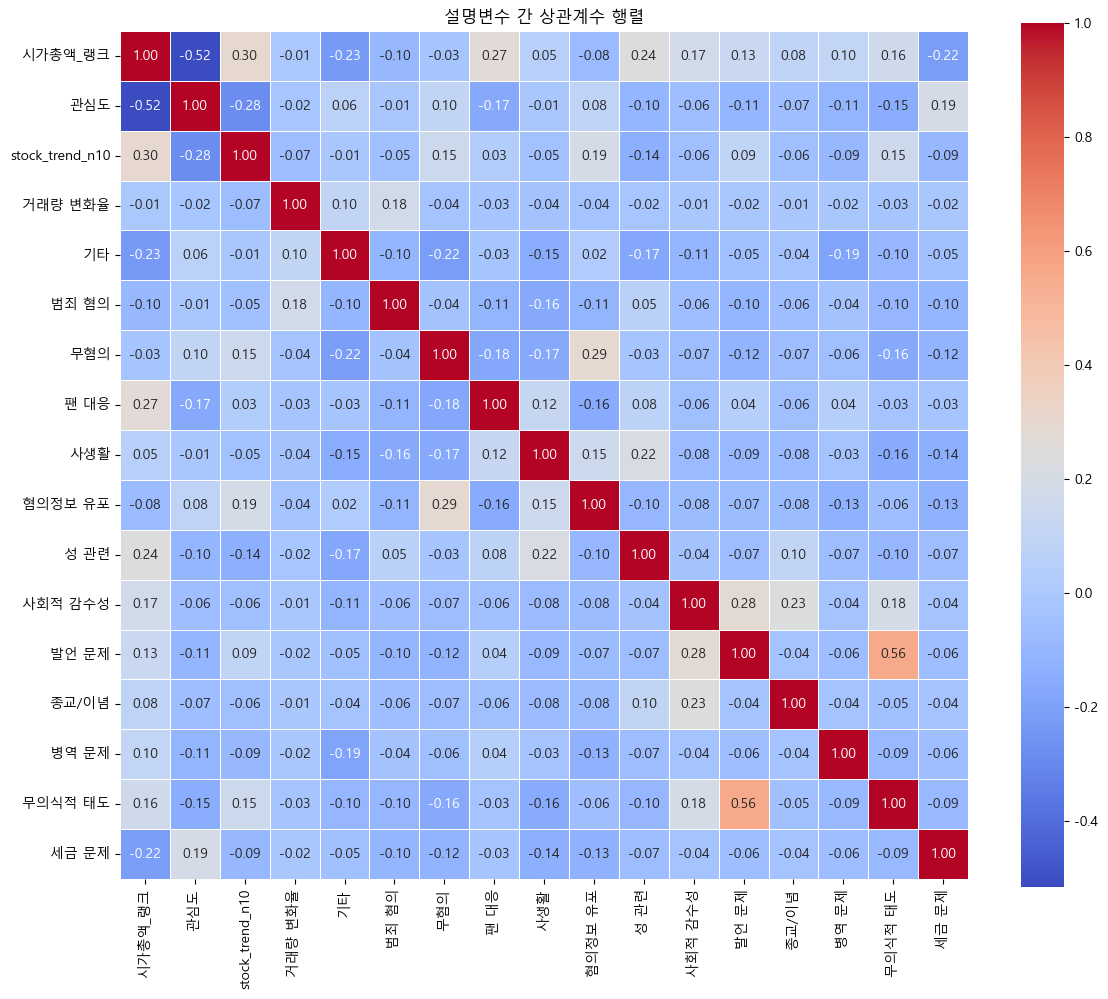

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# 상관계수 계산
corr_matrix = X_trainval.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("설명변수 간 상관계수 행렬")
plt.tight_layout()
plt.show()

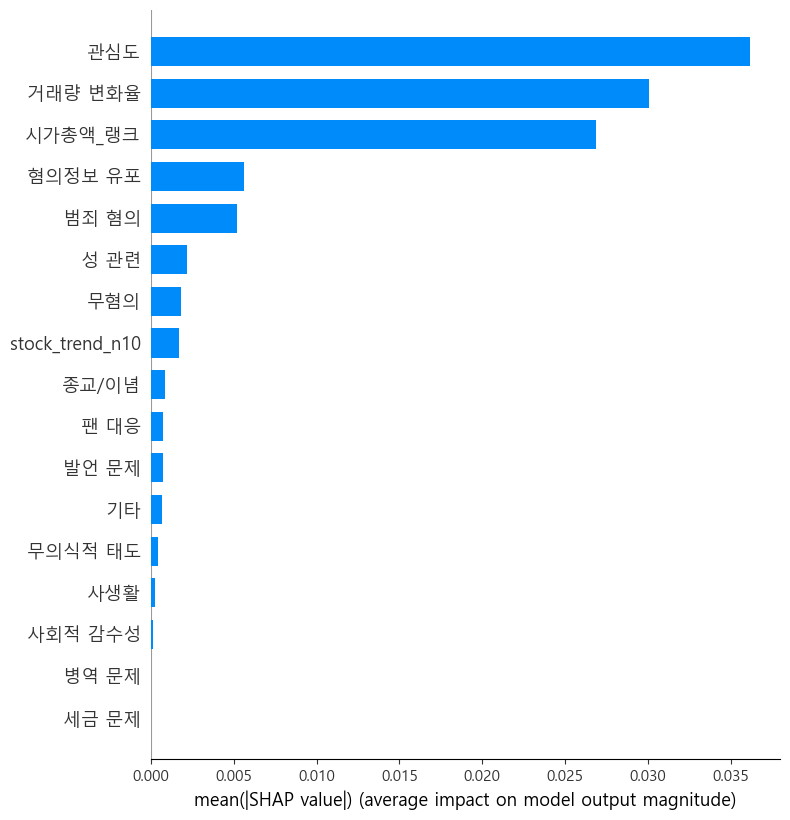

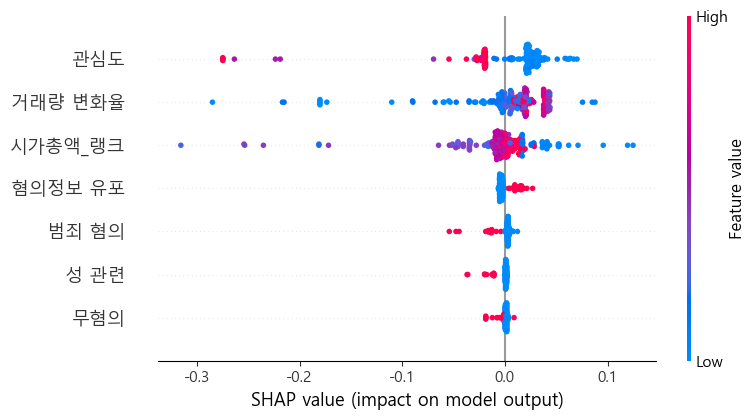

In [97]:
import shap

# SHAP explainer 생성 (TreeExplainer는 XGBoost와 호환됨)
explainer = shap.Explainer(grid_search.best_estimator_)

# SHAP 값 계산
shap_values = explainer(X_trainval)

# 요약 플롯
shap.summary_plot(shap_values, X_trainval, plot_type="bar")

# 상세 분포 플롯
shap.summary_plot(shap_values, X_trainval, max_display=7)



<Figure size 1000x600 with 0 Axes>

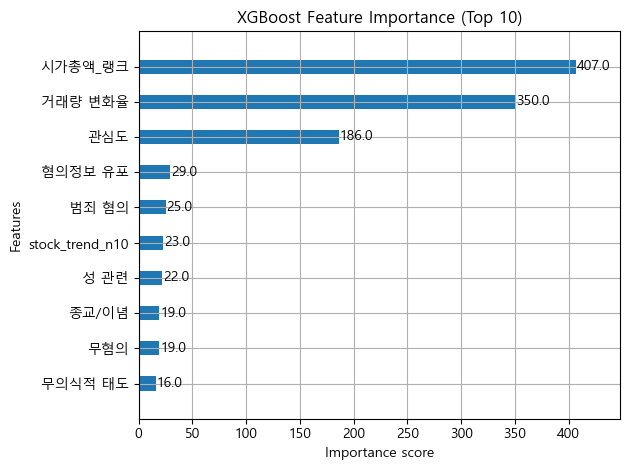

In [95]:
from xgboost import plot_importance

# 피처 중요도 시각화 (기본 기준: gain)
plt.figure(figsize=(10, 6))
plot_importance(grid_search.best_estimator_, max_num_features=10, height=0.4)
plt.title("XGBoost Feature Importance (Top 10)")
plt.tight_layout()
plt.show()